In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shriyashjagtap/e-commerce-customer-for-behavior-analysis/ecommerce_customer_data_large.csv
/kaggle/input/datasets/shriyashjagtap/e-commerce-customer-for-behavior-analysis/ecommerce_customer_data_custom_ratios.csv


#  Import Libraries

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

#  Load Dataset

In [4]:
df=pd.read_csv("/kaggle/input/datasets/shriyashjagtap/e-commerce-customer-for-behavior-analysis/ecommerce_customer_data_large.csv")
df

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0


#  Data Overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [6]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [7]:
df.describe(include='O')

,Purchase Date,Product Category,Payment Method,Customer Name,Gender
count,250000,250000,250000,250000,250000
unique,249728,4,3,39878,2
top,2021-11-30 18:52:48,Electronics,Credit Card,Michael Johnson,Male
freq,2,62630,83547,119,125676


In [8]:
df.columns.tolist()

['Customer ID',
 'Purchase Date',
 'Product Category',
 'Product Price',
 'Quantity',
 'Total Purchase Amount',
 'Payment Method',
 'Customer Age',
 'Returns',
 'Customer Name',
 'Age',
 'Gender',
 'Churn']

#  Check Missing Values and Duplicates

In [9]:
df.isna().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [10]:
df['Returns'] = df['Returns'].astype('object')
df['Returns'] = df['Returns'].fillna('No Return')
df['Returns'] = df['Returns'].astype(str)

#  Churn Distribution

<Axes: xlabel='Churn', ylabel='count'>

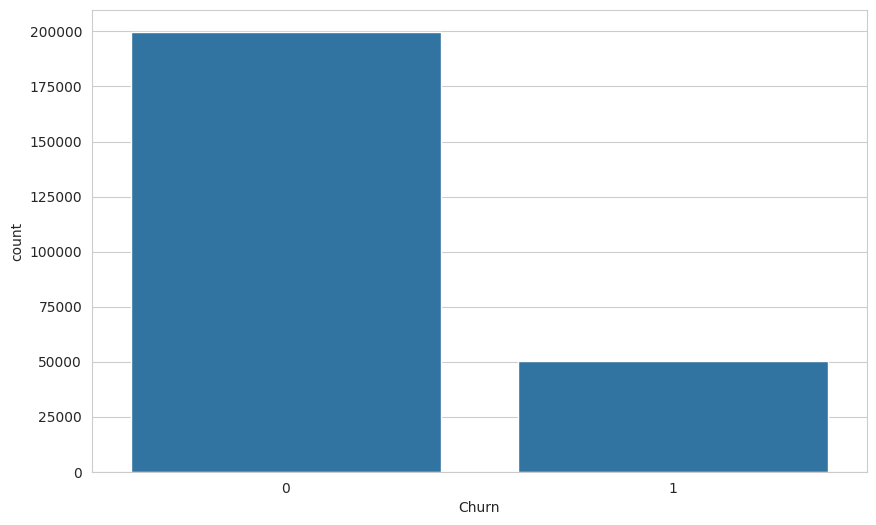

In [11]:
sns.countplot(x='Churn', data=df)

#  Gender Distribution

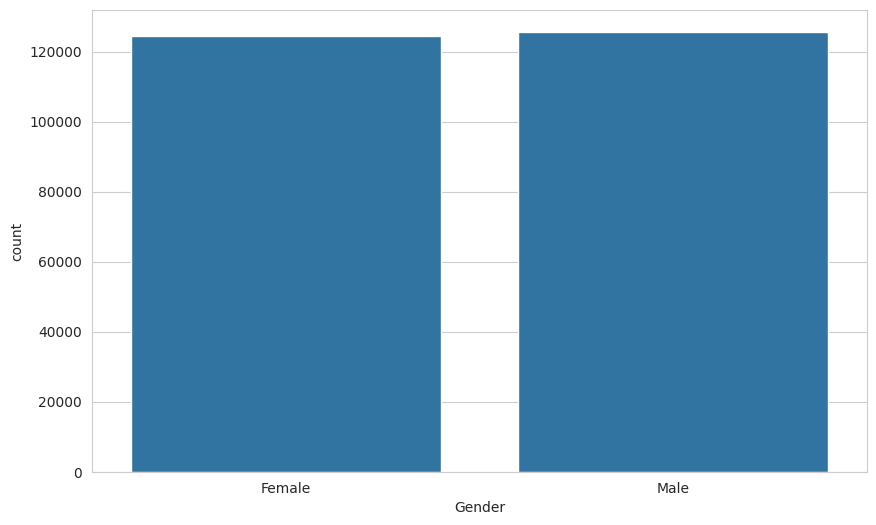

In [12]:
sns.countplot(x='Gender', data=df)

plt.show()

#  Product Category

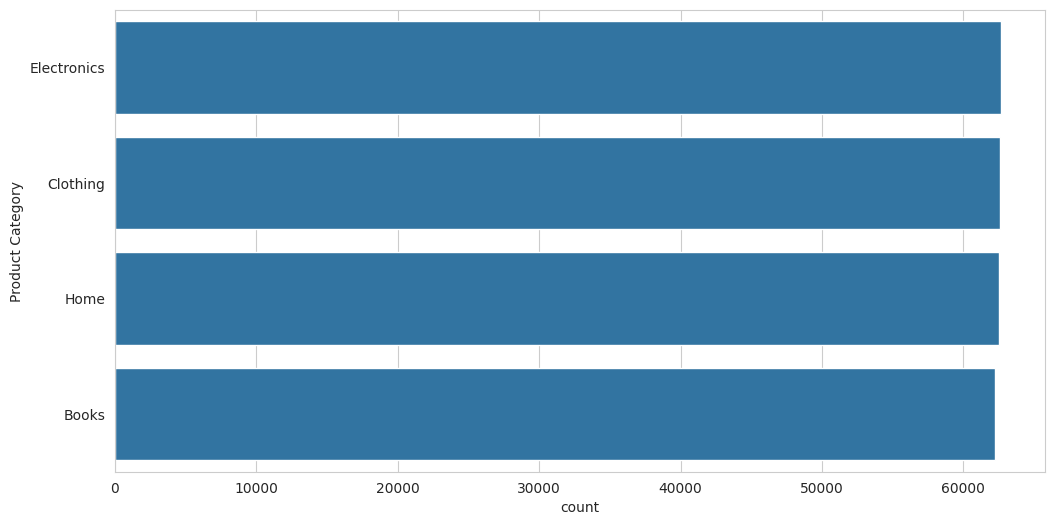

In [13]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Product Category',
    data=df,
    order=df['Product Category'].value_counts().index
)

plt.show()

# Payment Method vs Churn

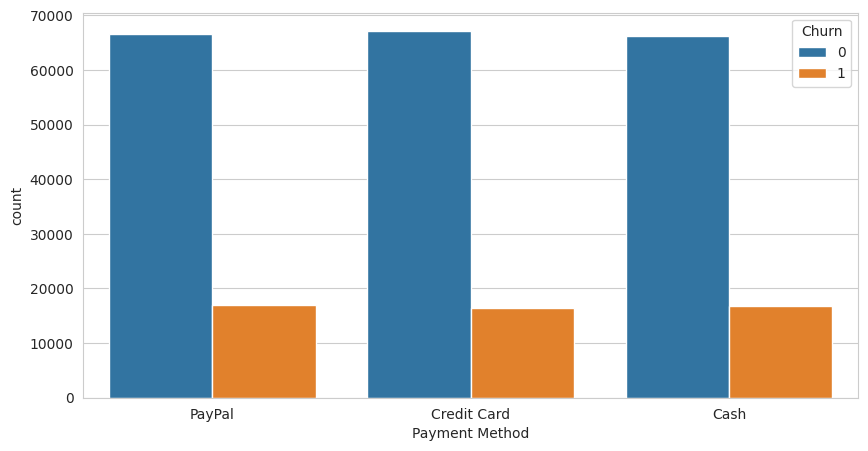

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Payment Method',
    hue='Churn',
    data=df
)

plt.show()

#  Age Distribution

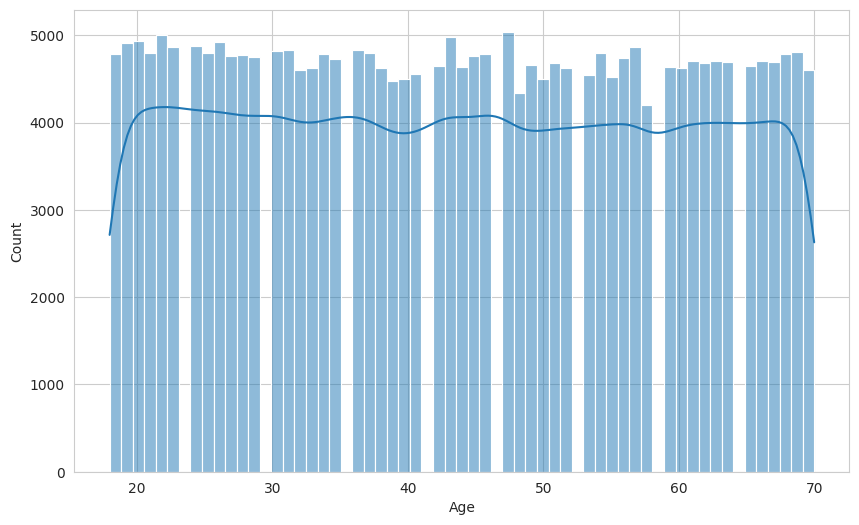

In [15]:
sns.histplot(df['Age'], kde=True)

plt.show()

In [16]:
le = LabelEncoder()

categorical_cols = [
    'Product Category',
    'Payment Method',
    'Gender',
    'Returns'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

#  Correlation Heatmap

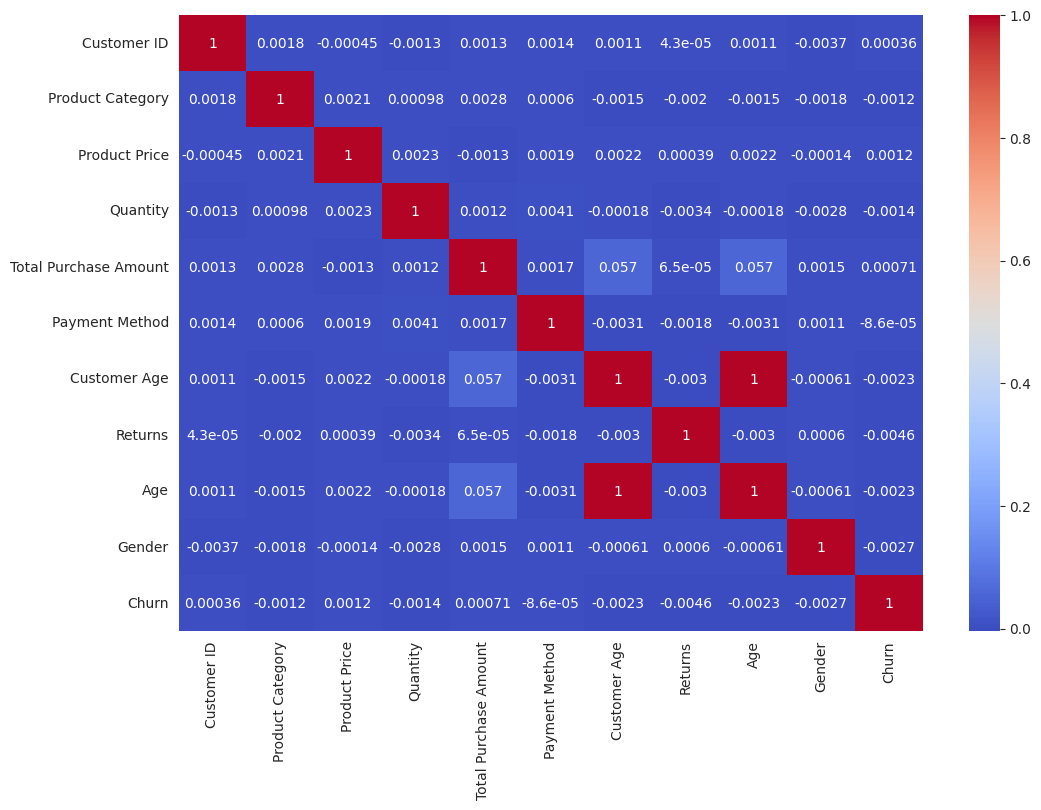

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [18]:
X = df.drop(['Churn', 'Customer ID', 'Customer Name'], axis=1)
y = df['Churn']

print(X.dtypes)

Purchase Date            object
Product Category          int64
Product Price             int64
Quantity                  int64
Total Purchase Amount     int64
Payment Method            int64
Customer Age              int64
Returns                   int64
Age                       int64
Gender                    int64
dtype: object


In [19]:
if 'Purchase Date' in df.columns:
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

    df['Purchase Year'] = df['Purchase Date'].dt.year
    df['Purchase Month'] = df['Purchase Date'].dt.month
    df['Purchase Day'] = df['Purchase Date'].dt.day
    df['Purchase Hour'] = df['Purchase Date'].dt.hour
    df['Purchase DayOfWeek'] = df['Purchase Date'].dt.dayofweek

    df = df.drop('Purchase Date', axis=1)

X = df.drop(['Churn', 'Customer ID', 'Customer Name'], axis=1)
y = df['Churn']

print(X.dtypes)

Product Category         int64
Product Price            int64
Quantity                 int64
Total Purchase Amount    int64
Payment Method           int64
Customer Age             int64
Returns                  int64
Age                      int64
Gender                   int64
Purchase Year            int32
Purchase Month           int32
Purchase Day             int32
Purchase Hour            int32
Purchase DayOfWeek       int32
dtype: object


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.80032
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     40016
           1       0.00      0.00      0.00      9984

    accuracy                           0.80     50000
   macro avg       0.40      0.50      0.44     50000
weighted avg       0.64      0.80      0.71     50000

[[40016     0]
 [ 9984     0]]


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.49866
              precision    recall  f1-score   support

           0       0.80      0.50      0.61     40016
           1       0.20      0.51      0.29      9984

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.45     50000
weighted avg       0.68      0.50      0.55     50000

[[19871 20145]
 [ 4922  5062]]


In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.80032
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     40016
           1       0.00      0.00      0.00      9984

    accuracy                           0.80     50000
   macro avg       0.40      0.50      0.44     50000
weighted avg       0.64      0.80      0.71     50000

[[40016     0]
 [ 9984     0]]


# Feature Importance

                  Feature  Importance
3   Total Purchase Amount    0.150703
1           Product Price    0.145182
11           Purchase Day    0.105399
12          Purchase Hour    0.101676
10         Purchase Month    0.078969
7                     Age    0.069082
5            Customer Age    0.069004
13     Purchase DayOfWeek    0.060240
2                Quantity    0.050686
9           Purchase Year    0.042878
0        Product Category    0.042608
4          Payment Method    0.033083
6                 Returns    0.031091
8                  Gender    0.019400


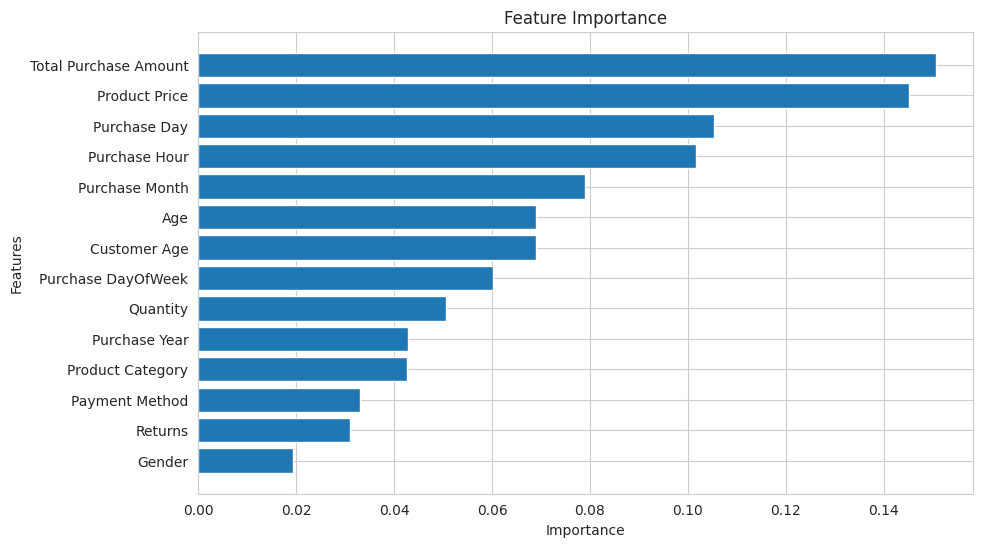

In [23]:


importance = rf.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_importance = feat_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feat_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feat_importance['Feature'],
    feat_importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

#  ROC Curve

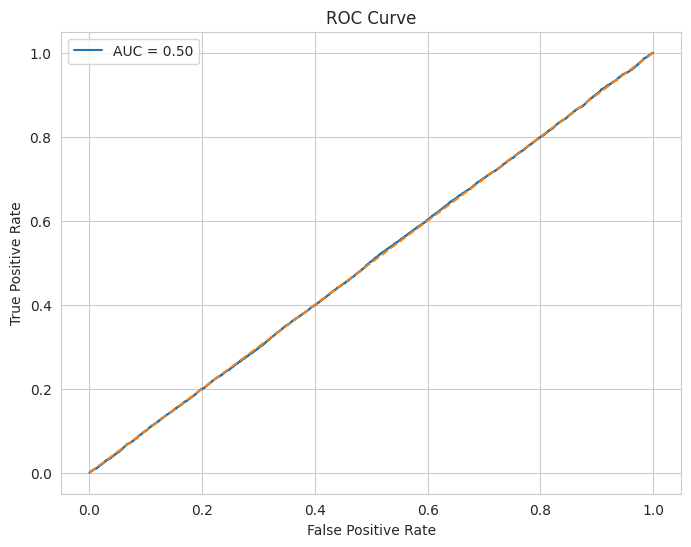

In [24]:

y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

# Hyperparameter Tuning


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [26]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [27]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_best))

print(classification_report(
    y_test,
    y_pred_best,
    zero_division=0
))

Accuracy: 0.55466
              precision    recall  f1-score   support

           0       0.81      0.58      0.68     40016
           1       0.21      0.44      0.28      9984

    accuracy                           0.55     50000
   macro avg       0.51      0.51      0.48     50000
weighted avg       0.69      0.55      0.60     50000



# Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.56206 0.5788  0.60562 0.58008 0.60162]
Average CV Accuracy: 0.585636


# Final Model Selection

In [29]:
results = pd.DataFrame({
    'Model': ['Logistic Regression Balanced', 'Random Forest Balanced'],
    'Accuracy': [0.4988, 0.5547],
    'Recall_Churn': [0.51, 0.44],
    'F1_Churn': [0.29, 0.28]
})

results

,Model,Accuracy,Recall_Churn,F1_Churn
0,Logistic Regression Balanced,0.4988,0.51,0.29
1,Random Forest Balanced,0.5547,0.44,0.28


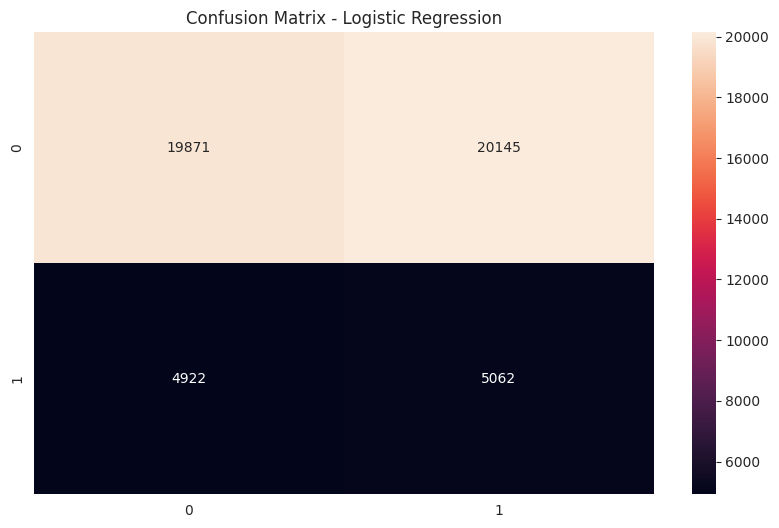

In [30]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [31]:
print("Best Model Selection")

print("""
Although Random Forest achieved higher accuracy,
it completely failed to identify churn customers.

Logistic Regression with class balancing achieved
better recall for churn prediction, making it
more useful for business decision-making.
""")

Best Model Selection

Although Random Forest achieved higher accuracy,
it completely failed to identify churn customers.

Logistic Regression with class balancing achieved
better recall for churn prediction, making it
more useful for business decision-making.

